# Klassificering av ansiktsuttryck med CNN och Deep Learning

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import time

import tensorflow as tf
from sklearn.metrics import accuracy_score

from utils import (
    plot_history,
    predict_classes,
    plot_confusion_matrix,
    calculate_per_class_accuracy,
    get_most_confused_pairs,
    plot_misclassified_examples,
    extract_dataset,
    show_prediction
)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 1. Förstå och undersöka datan

### 1.1 Datasetets uppbyggnad

Börjar med att undersöka hur datasetet är uppbyggt

Datasetet är uppdelat i:
- träningsdata (`train`)
- testdata (`test`)

Varje klass ligger i en egen mapp, vilket gör att bilderna automatiskt kan kopplas till rätt etikett vid inläsning.

Därefter undersöks vilka klasser som finns och om train/test innehåller samma etiketter.


In [3]:
data_path = 'Data'

print('Mappar i datasetet:')
print(os.listdir(data_path))


train_path = os.path.join(data_path, 'train')
test_path = os.path.join(data_path, 'test')


classes_train = sorted(os.listdir(train_path))
classes_test = sorted(os.listdir(test_path))

num_classes = len(classes_train)

print('\nAntal klasser:', num_classes)

print('\nKlasser:')
print(classes_train)

print('\nSamma klasser i train och test:')
print(classes_train == classes_test)

Mappar i datasetet:
['test', 'train']

Antal klasser: 7

Klasser:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Samma klasser i train och test:
True


### 1.2 Klassfördelning i datasetet

För att förstå datans balans analyseras antalet bilder per klass i både tränings- och testdata.

Detta är viktigt eftersom klassobalans kan påverka modellens inlärning och leda till sämre resultat för minoritetsklasser.

In [4]:
data = []

total_train = 0
total_test = 0

for class_name in classes_train:

    train_count = len(os.listdir(os.path.join(train_path, class_name)))
    test_count = len(os.listdir(os.path.join(test_path, class_name)))

    total_train += train_count
    total_test += test_count

    data.append([
        class_name,
        train_count,
        test_count
    ])


df = pd.DataFrame(
    data,
    columns=['Klass', 'Train', 'Test']
)

df['Train %'] = round((df['Train'] / total_train) * 100, 2)
df['Test %'] = round((df['Test'] / total_test) * 100, 2)

df_sorted = df.sort_values("Train", ascending=False)

display(df_sorted)

print(f'Totalt antal träningsbilder: {total_train}')
print(f'Totalt antal testbilder: {total_test}')

,Klass,Train,Test,Train %,Test %
3,happy,7215,1774,25.13,24.71
4,neutral,4965,1233,17.29,17.18
5,sad,4830,1247,16.82,17.37
2,fear,4097,1024,14.27,14.27
0,angry,3995,958,13.92,13.35
6,surprise,3171,831,11.05,11.58
1,disgust,436,111,1.52,1.55


Totalt antal träningsbilder: 28709
Totalt antal testbilder: 7178


### 1.3 Visualisering av klassfördelning

Stapeldiagrammet visar hur bilderna är fördelade mellan klasserna i train och test.

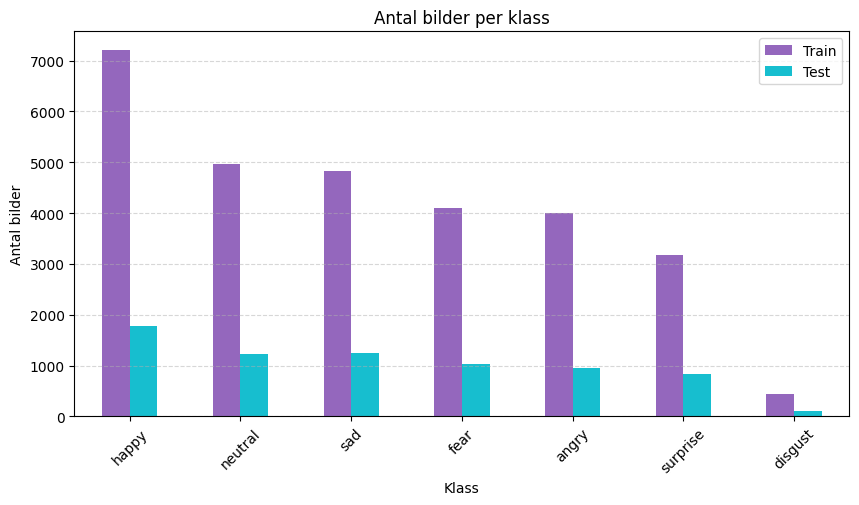

In [5]:
df_sorted.plot(
    x="Klass",
    y=["Train", "Test"],
    kind="bar",
    figsize=(10, 5),
    color=["#9467bd", "#17becf"]
)

plt.title("Antal bilder per klass")
plt.ylabel("Antal bilder")
plt.xticks(rotation=45)
plt.legend(["Train", "Test"])
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### 1.4 Visuell kontroll av datasetet

Först visas ett exempel från en klass för att kontrollera bildens format och kvalitet.   
Därefter visas ett exempel från varje klass för att få en översikt över variationen i datasetet.

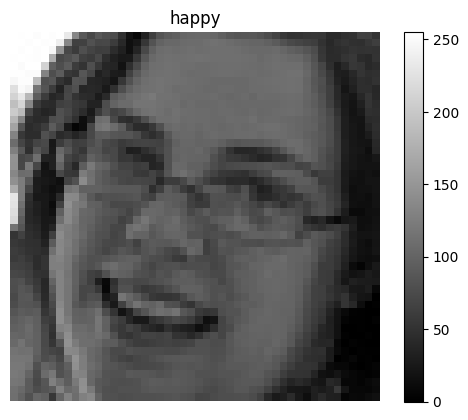

Bildens storlek: (48, 48)


In [6]:
example_class = "happy"
example_path = os.path.join(train_path, example_class)

img_name = os.listdir(example_path)[0]
img_path = os.path.join(example_path, img_name)

img = mpimg.imread(img_path)

plt.imshow(img, cmap="gray")
plt.title(example_class)
plt.colorbar()
plt.axis("off")
plt.show()

print('Bildens storlek:', img.shape)

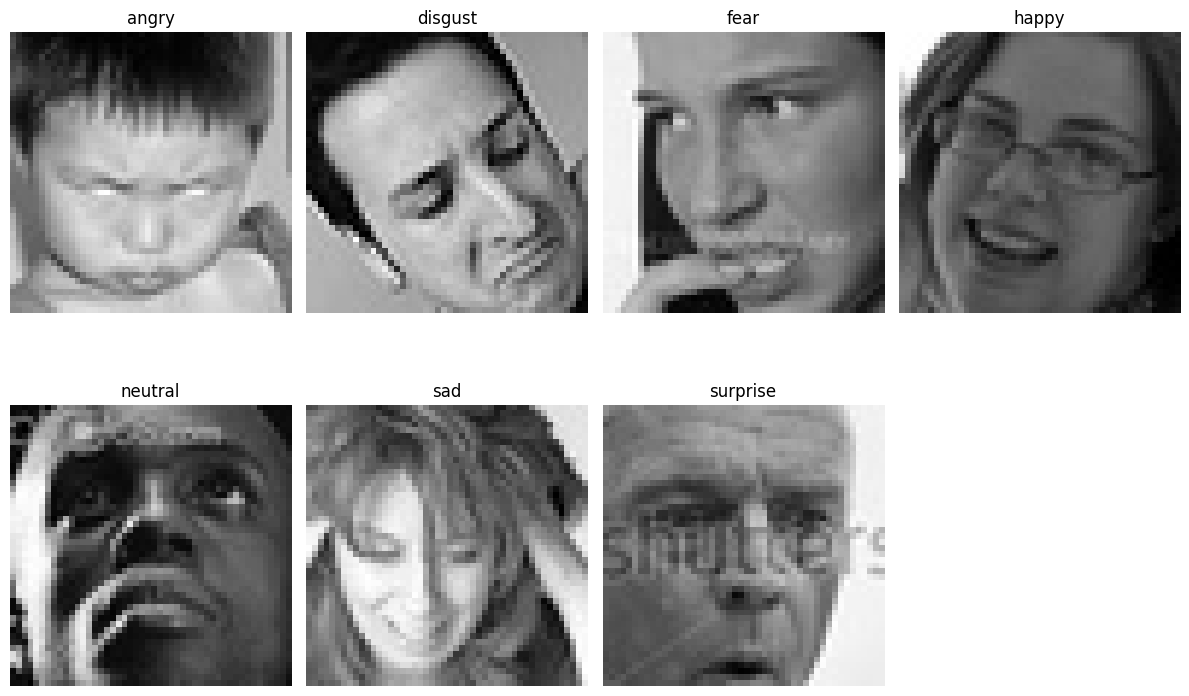

In [7]:
plt.figure(figsize=(12, 8))

for i, c in enumerate(classes_train):
    path = os.path.join(train_path, c)

    img_name = os.listdir(path)[0]
    img_path = os.path.join(path, img_name)

    img = mpimg.imread(img_path)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 1.5 Datasetanalys

Datasetet består av bilder uppdelade i sju olika ansiktsuttryck: angry, disgust, fear, happy, neutral, sad och surprise.  
För varje klass finns både tränings- och testdata.

En analys av klassfördelningen visar att datan är tydligt obalanserad. Vissa klasser, såsom happy och neutral, innehåller betydligt fler bilder än exempelvis disgust och fear.

Denna obalans är viktig att beakta eftersom den kan påverka modellens inlärning. Modellen riskerar att bli bättre på majoritetsklasser och sämre på minoritetsklasser.

Utöver den kvantitativa analysen genomfördes även en visuell granskning av ett urval av bilder från datasetet för att bättre förstå datans karaktär.

Denna inspektion visade att bilderna varierar i både kvalitet, ljussättning och ansiktsposition. Vissa bilder är tydliga och välcentrerade, medan andra innehåller mer brus, låg kontrast eller delvis skymda ansikten.

**Slutsats och lösning**  
För att hantera detta används både modellarkitektur med regularisering samt data augmentation i senare modeller, i syfte att förbättra generalisering och minska överanpassning till dominerande klasser


## 2. Förberedelse av data

### 2.1 Inläsning och uppdelning av dataset

Datasetet läses in med `image_dataset_from_directory`, vilket automatiskt kopplar varje bild till rätt klass baserat på mappstrukturen.

Träningsdatan delas därefter upp i:
- träningsdata
- validationsdata (20 %)

Validation används under träningen för att följa modellens generalisering och upptäcka eventuell overfitting.

Samtliga bilder:
- skalas till 48x48 pixlar
- läses in som gråskalebilder
- batchas i grupper om 32


In [8]:
img_height = 48
img_width = 48
batch_size = 32
seed = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="grayscale"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="grayscale"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="grayscale",
    shuffle=False
)

class_names = train_dataset.class_names
print('Klassnamn: ', class_names)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.
Klassnamn:  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### 2.2 Normalisering och optimering av dataset

För att stabilisera träningen normaliseras pixelvärdena från intervallet 0–255 till 0–1.  
Detta gör att modellen tränas mer effektivt.

Dataseten optimeras även med prefetch(), vilket förbättrar prestandan genom att förbereda nästa batch medan modellen tränar på den nuvarande.

Slutligen kontrolleras:
- batcharnas dimensioner
- att normaliseringen fungerar korrekt

In [9]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)

validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)

test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y)).prefetch(AUTOTUNE)


print('Train dataset batch shape:')
for images, labels in train_dataset.take(1):
    print(images.shape)

print('Pixel range check:')
for images, labels in train_dataset.take(1):
    print("Min:", images.numpy().min(),
          "Max:", images.numpy().max())

Train dataset batch shape:
(32, 48, 48, 1)
Pixel range check:
Min: 0.0 Max: 1.0


### 2.3 Dataset-varianter för experiment

Eftersom datasetet är relativt stort skapas flera mindre versioner av tränings- och validationsdatan.  
Syftet är att snabbare kunna testa olika modeller och minska träningstiden under utvecklingen
- Small v1: används för baseline-modell
- Small v2: används för förbättrad modell
- Full dataset: används för slutliga modeller

**Extraktion av data**  
Extraherar valideringsdata till numpy-format för att möjliggöra utvärdering (accuracy, confusion matrix etc.) .
Detta används i senare analyser där prediktioner jämförs direkt mot sanna etiketter.

**Datasetstorlek och kontroll**  
Slutligen verifieras storleken på varje dataset-variant för att säkerställa korrekt uppdelning.
Detta görs genom att räkna antal batches och multiplicera med batch-storlek.

In [10]:
# SMALL VERSION 1 (baseline)
train_dataset_small_v1 = train_dataset.take(100)
validation_dataset_small_v1 = validation_dataset.take(25)

# SMALL VERSION 2 (improved)
train_dataset_small_v2 = train_dataset.take(200)
validation_dataset_small_v2 = validation_dataset.take(50)

# FULL DATASET (improved_2 + final)
train_dataset_full = train_dataset
validation_dataset_full = validation_dataset


# Baseline eval data
X_val_small_v1, y_val_small_v1 = extract_dataset(validation_dataset_small_v1)

# Improved eval data
X_val_small_v2, y_val_small_v2 = extract_dataset(validation_dataset_small_v2)

# Full eval data
X_val_full, y_val_full = extract_dataset(validation_dataset_full)

print('=== ÖVERBLICK DATASET ===')

for name, train_ds, val_ds in [
    ('v1', train_dataset_small_v1, validation_dataset_small_v1),
    ('v2', train_dataset_small_v2, validation_dataset_small_v2),
    ('full', train_dataset_full, validation_dataset_full)
]:
    train_batches = tf.data.experimental.cardinality(train_ds).numpy()
    val_batches = tf.data.experimental.cardinality(val_ds).numpy()

    print(f"\n{name}")
    print('Antal train bilder:      ', train_batches * batch_size)
    print('Antal validation bilder: ', val_batches * batch_size)

=== ÖVERBLICK DATASET ===

v1
Antal train bilder:       3200
Antal validation bilder:  800

v2
Antal train bilder:       6400
Antal validation bilder:  1600

full
Antal train bilder:       22976
Antal validation bilder:  5760


## 3. Test av olika modeller

I detta steg testas flera CNN-modeller med olika arkitekturer och inställningar för att undersöka hur modellernas prestanda påverkas.

Arbetet börjar med en enklare baseline-modell som sedan förbättras stegvis genom exempelvis:
- större dataset
- fler lager
- dropout
- data augmentation

För att kunna jämföra modellerna skapas en tom lista (`results`) där viktiga resultat från varje modell sparas.

Efter varje träning analyseras modellernas utveckling genom både träningshistorik och prediktioner på valideringsdatan.

Följande analyser genomförs för varje modell:
- tränings- och valideringskurvor analyseras för att identifiera inlärning och eventuell over/underfitting
- den epok med lägst validation loss identifieras för att hitta modellens bästa generalisering
- prediktioner görs på valideringsdatan
- validation accuracy beräknas
- confusion matrix och accuracy per klass analyseras
- vanliga felklassificeringar undersöks
- felklassificerade bilder analyseras visuellt

Detta gör det möjligt att jämföra modellernas styrkor, svagheter och generaliseringsförmåga samt undersöka hur olika arkitektur- och träningsval påverkar resultaten.

### 3.1 Resultatlista för modelljämförelser

En tom lista skapas för att samla resultat från samtliga modeller.
Detta gör det enklare att senare jämföra modellernas prestanda.

In [11]:
results = []

### 3.2.1 Baseline CNN

Den första modellen fungerar som en baseline för senare jämförelser.
Arkitekturen är relativt enkel och används för att skapa en grundnivå att jämföra förbättrade modeller mot.

Modellen består av:
- två convolutional-lager
- max pooling
- ett fullt kopplat dense-lager
- softmax-output för klassificering

In [12]:
base_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

base_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2.2 Träning av baseline-modellen

Baseline-modellen tränas på den mindre dataset-versionen (small_v1) för snabbare experimentering och kortare träningstid.

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2669 - loss: 1.8172 - val_accuracy: 0.2237 - val_loss: 1.8238
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3047 - loss: 1.7313 - val_accuracy: 0.3137 - val_loss: 1.7324
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3684 - loss: 1.6108 - val_accuracy: 0.3288 - val_loss: 1.7062
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4178 - loss: 1.5065 - val_accuracy: 0.3725 - val_loss: 1.6457
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.4697 - loss: 1.4147 - val_accuracy: 0.3775 - val_loss: 1.6382
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5125 - loss: 1.3268 - val_accuracy: 0.3800 - val_loss: 1.6210
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5384 - loss: 1.2475 - val_accuracy: 0.3475 - val_loss: 1.7370
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5847 - loss: 1.1350 - val_accu

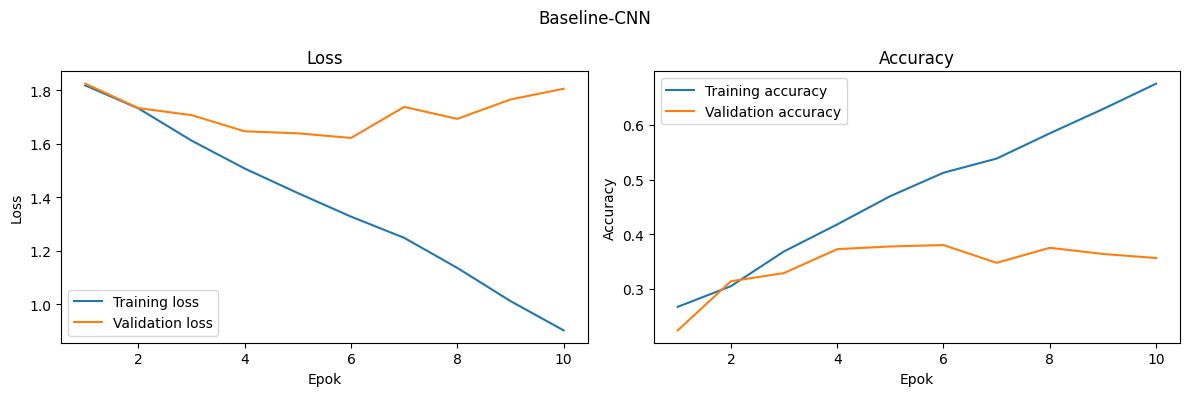

In [13]:
start_time = time.time()

base_history = base_model.fit(
    train_dataset_small_v1,
    validation_data=validation_dataset_small_v1,
    epochs=10
)

training_time = time.time() - start_time

print(f'Träningstid: {training_time / 60:.2f} minuter')

plot_history(base_history, title='Baseline-CNN')

### 3.2.3 Observationer från träningen

Modellen förbättras tydligt under de första epokerna och träningsaccuracy fortsätter att öka över tid.

Samtidigt planar validation accuracy ut relativt tidigt medan validation loss börjar öka efter några epoker.

Detta tyder på att modellen börjar overfitta träningsdatan och får svårare att generalisera till ny data.

In [14]:
base_history_df = pd.DataFrame(base_history.history)

best_epoch = base_history_df['val_loss'].idxmin() + 1
best_val_loss = base_history_df['val_loss'].min()
best_val_accuracy = base_history_df['val_accuracy'].iloc[best_epoch - 1]

print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')


base_y_pred, base_y_proba = predict_classes(base_model, X_val_small_v1)
base_val_acc = accuracy_score(y_val_small_v1, base_y_pred)

print(f"Baseline validation accuracy: {base_val_acc:.4f}")



Bästa validation loss vid epok: 6
Bästa validation loss: 1.6210
Validation accuracy vid den epoken: 0.3800
Baseline validation accuracy: 0.3400


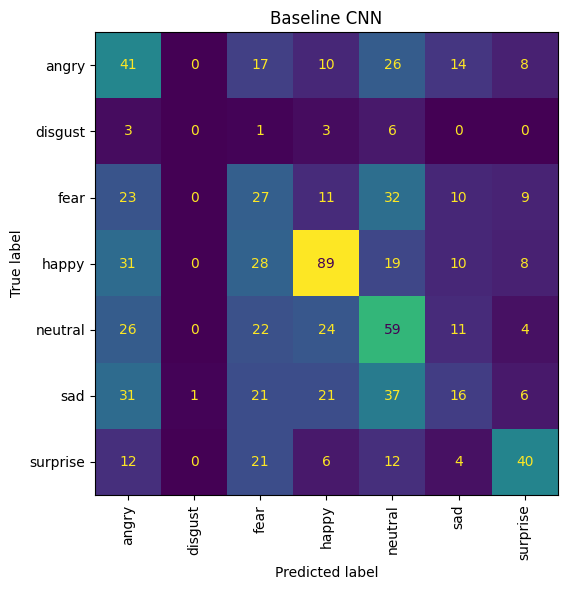

,class_id,class_name,support,correct,accuracy
1,1,disgust,13,0,0.000000
5,5,sad,133,16,0.120301
2,2,fear,112,27,0.241071
0,0,angry,116,41,0.353448
4,4,neutral,146,59,0.404110
6,6,surprise,95,40,0.421053
3,3,happy,185,89,0.481081


,true_class,predicted_class,count
28,sad,neutral,37
11,fear,neutral,32
24,sad,angry,31
14,happy,angry,31
15,happy,fear,28
2,angry,neutral,26
19,neutral,angry,26
21,neutral,happy,24
9,fear,angry,23
20,neutral,fear,22


In [15]:
base_cm = plot_confusion_matrix(
    y_val_small_v1,
    base_y_pred,
    class_names,
    title="Baseline CNN"
)

base_per_class = calculate_per_class_accuracy(
    base_cm,
    class_names
)

display(base_per_class)

base_confusions = get_most_confused_pairs(
    base_cm,
    class_names
)

display(base_confusions)

Antal felklassificerade exempel: 528
Andel felklassificerade: 66.00%


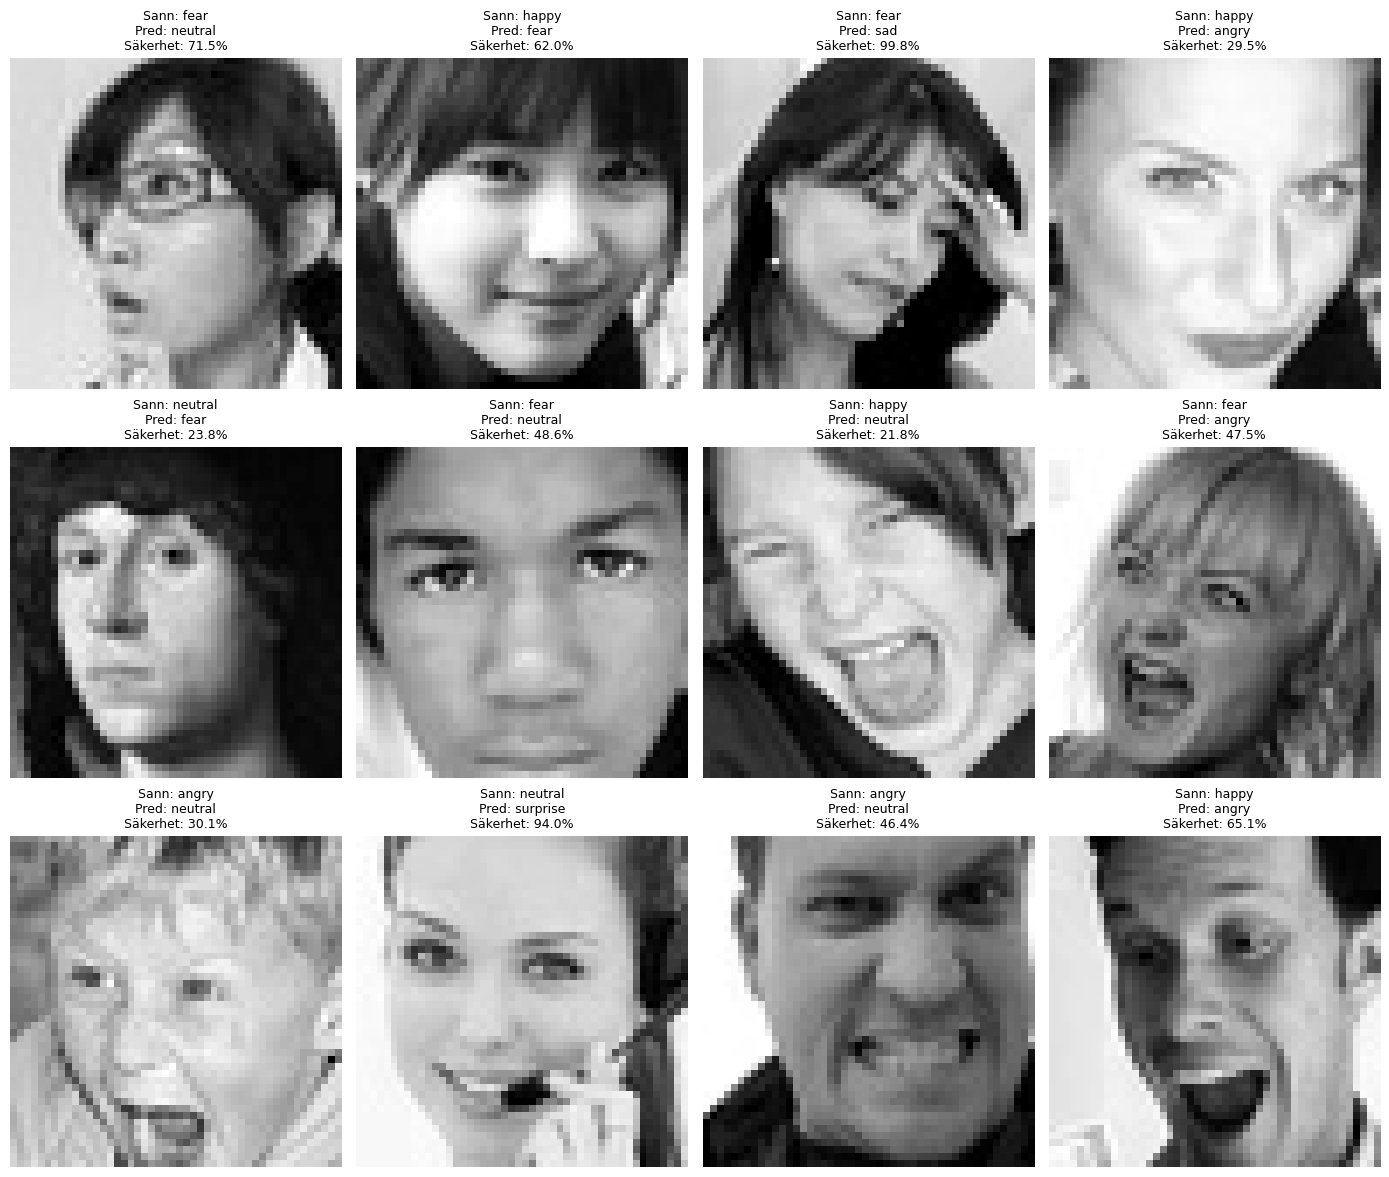

In [16]:
plot_misclassified_examples(
    X_val_small_v1,
    y_val_small_v1,
    base_y_pred,
    base_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [17]:
results.append({
    "model": "baseline",
    "val_acc": base_val_acc,
    "val_loss": base_history_df["val_loss"].min(),
    "epochs_trained": len(base_history_df),
    "training_time_min": training_time / 60
})

results_df = pd.DataFrame(results)
display(results_df)

,model,val_acc,val_loss,epochs_trained,training_time_min
0,baseline,0.34,1.620953,10,0.279672


### 3.2.4 Sammanfattning av baseline-modellen

Baseline-modellen lyckas lära sig grundläggande mönster i datan men visar tydliga tecken på overfitting.

Resultatet visar även att vissa klasser är betydligt svårare att klassificera än andra. 

Klasser med fler träningsbilder presterar generellt bättre, medan minoritetsklasser som disgust och fear har betydligt lägre accuracy.

Analysen visar även att modellen ofta förväxlar visuellt liknande ansiktsuttryck.

Flera felklassificerade exempel innehåller uttryck som även för människor kan vara svåra att tolka tydligt.

I vissa fall gör modellen felaktiga prediktioner med relativt hög säkerhet, vilket tyder på att modellen ännu inte generaliserar tillräckligt bra.

Resultatet visar samtidigt att modellen fungerar som en stabil grund för vidare förbättringar


### ### 3.3.1 Improved CNN 

För att minska overfitting och förbättra modellens generalisering testas en mer avancerad CNN-modell 

Jämfört med baseline-modellen används:
- fler convolutional layers
- dropout
- ett större dataset

Dropout används för att minska risken att modellen anpassar sig för mycket till träningsdatan och därmed förbättra generaliseringsförmågan.

In [18]:
improved_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(48, 48, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,245,671 (4.75 MB)

 Trainable params: 1,245,671 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

### 3.3.2 Träning av den förbättrade modellen

Den förbättrade modellen tränas på den större dataset-versionen (small_v2) för att ge modellen tillgång till mer träningsdata.

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.2422 - loss: 1.8346 - val_accuracy: 0.2450 - val_loss: 1.8061
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.2695 - loss: 1.7796 - val_accuracy: 0.2944 - val_loss: 1.7323
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.3036 - loss: 1.7178 - val_accuracy: 0.3400 - val_loss: 1.6786
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.3587 - loss: 1.6496 - val_accuracy: 0.3688 - val_loss: 1.6022
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.3856 - loss: 1.5873 - val_accuracy: 0.3944 - val_loss: 1.5693
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.4128 - loss: 1.5099 - val_accuracy: 0.4244 - val_loss: 1.5003
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.4412 - loss: 1.4448 - val_accuracy: 0.4238 - val_loss: 1.4764
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.4759 - loss: 1.3845 - val_accu

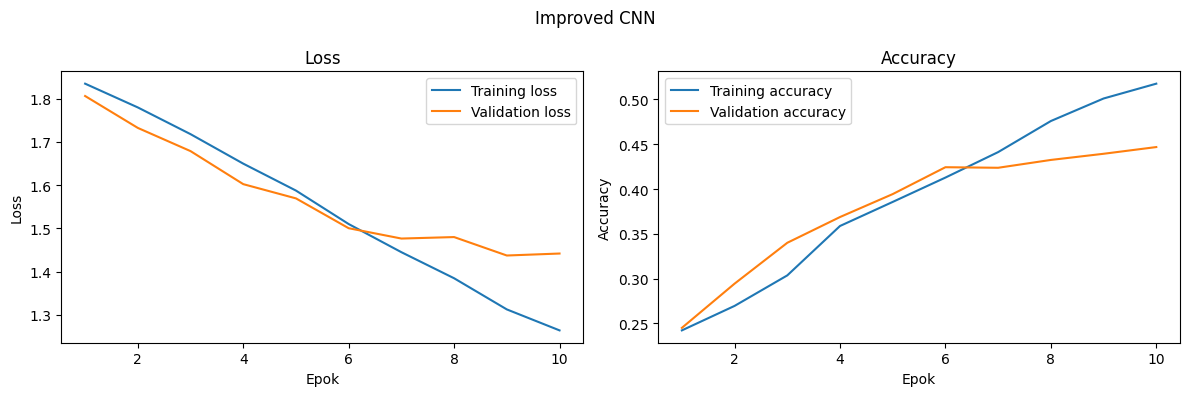

In [19]:
start_time = time.time()

improved_history = improved_model.fit(
    train_dataset_small_v2,
    validation_data=validation_dataset_small_v2,
    epochs=10
)

training_time = time.time() - start_time

print(f'Träningstid: {training_time / 60:.2f} minuter')

plot_history(improved_history, title="Improved CNN")

### 3.3.3 Observationer från träningen

Modellen förbättras successivt under hela träningen och både tränings- och validation accuracy ökar stabilt över flera epoker.

Till skillnad från baseline-modellen syns mindre tydliga tecken på overfitting, vilket tyder på att dropout och den större datamängden bidrar till bättre generalisering.

Validation loss fortsätter dessutom att minska genom större delen av träningen, vilket indikerar att modellen fortfarande lär sig relevanta mönster i datan.

In [20]:
improved_history_df = pd.DataFrame(improved_history.history)

best_epoch = improved_history_df['val_loss'].idxmin() + 1
best_val_loss = improved_history_df['val_loss'].min()
best_val_accuracy = improved_history_df['val_accuracy'].iloc[best_epoch - 1]

print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')

improved_y_pred, improved_y_proba = predict_classes(
    improved_model,
    X_val_small_v2
)

improved_val_acc = accuracy_score(y_val_small_v2, improved_y_pred)

print(f"Improved validation accuracy: {improved_val_acc:.4f}")

Bästa validation loss vid epok: 9
Bästa validation loss: 1.4371
Validation accuracy vid den epoken: 0.4394
Improved validation accuracy: 0.4419


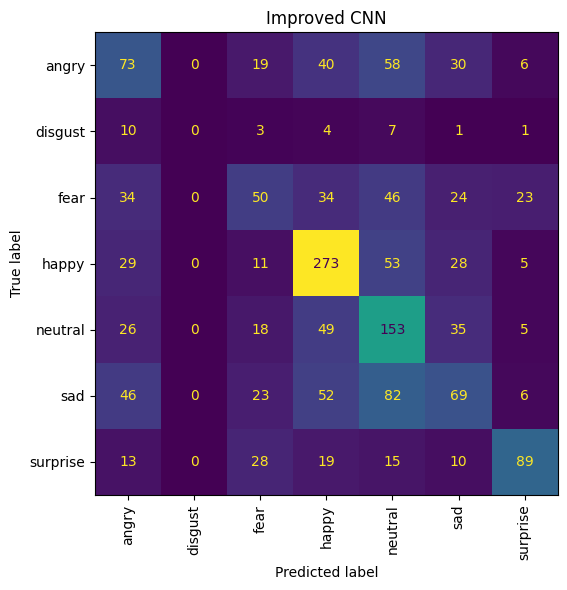

,class_id,class_name,support,correct,accuracy
1,1,disgust,26,0,0.000000
2,2,fear,211,50,0.236967
5,5,sad,278,69,0.248201
0,0,angry,226,73,0.323009
6,6,surprise,174,89,0.511494
4,4,neutral,286,153,0.534965
3,3,happy,399,273,0.684211


,true_class,predicted_class,count
29,sad,neutral,82
2,angry,neutral,58
18,happy,neutral,53
28,sad,happy,52
23,neutral,happy,49
26,sad,angry,46
13,fear,neutral,46
1,angry,happy,40
24,neutral,sad,35
11,fear,angry,34


In [21]:
improved_cm = plot_confusion_matrix(
    y_val_small_v2,
    improved_y_pred,
    class_names,
    title="Improved CNN"
)

improved_per_class = calculate_per_class_accuracy(
    improved_cm,
    class_names
)

display(improved_per_class)

improved_confusions = get_most_confused_pairs(
    improved_cm,
    class_names
)

display(improved_confusions)

Antal felklassificerade exempel: 893
Andel felklassificerade: 55.81%


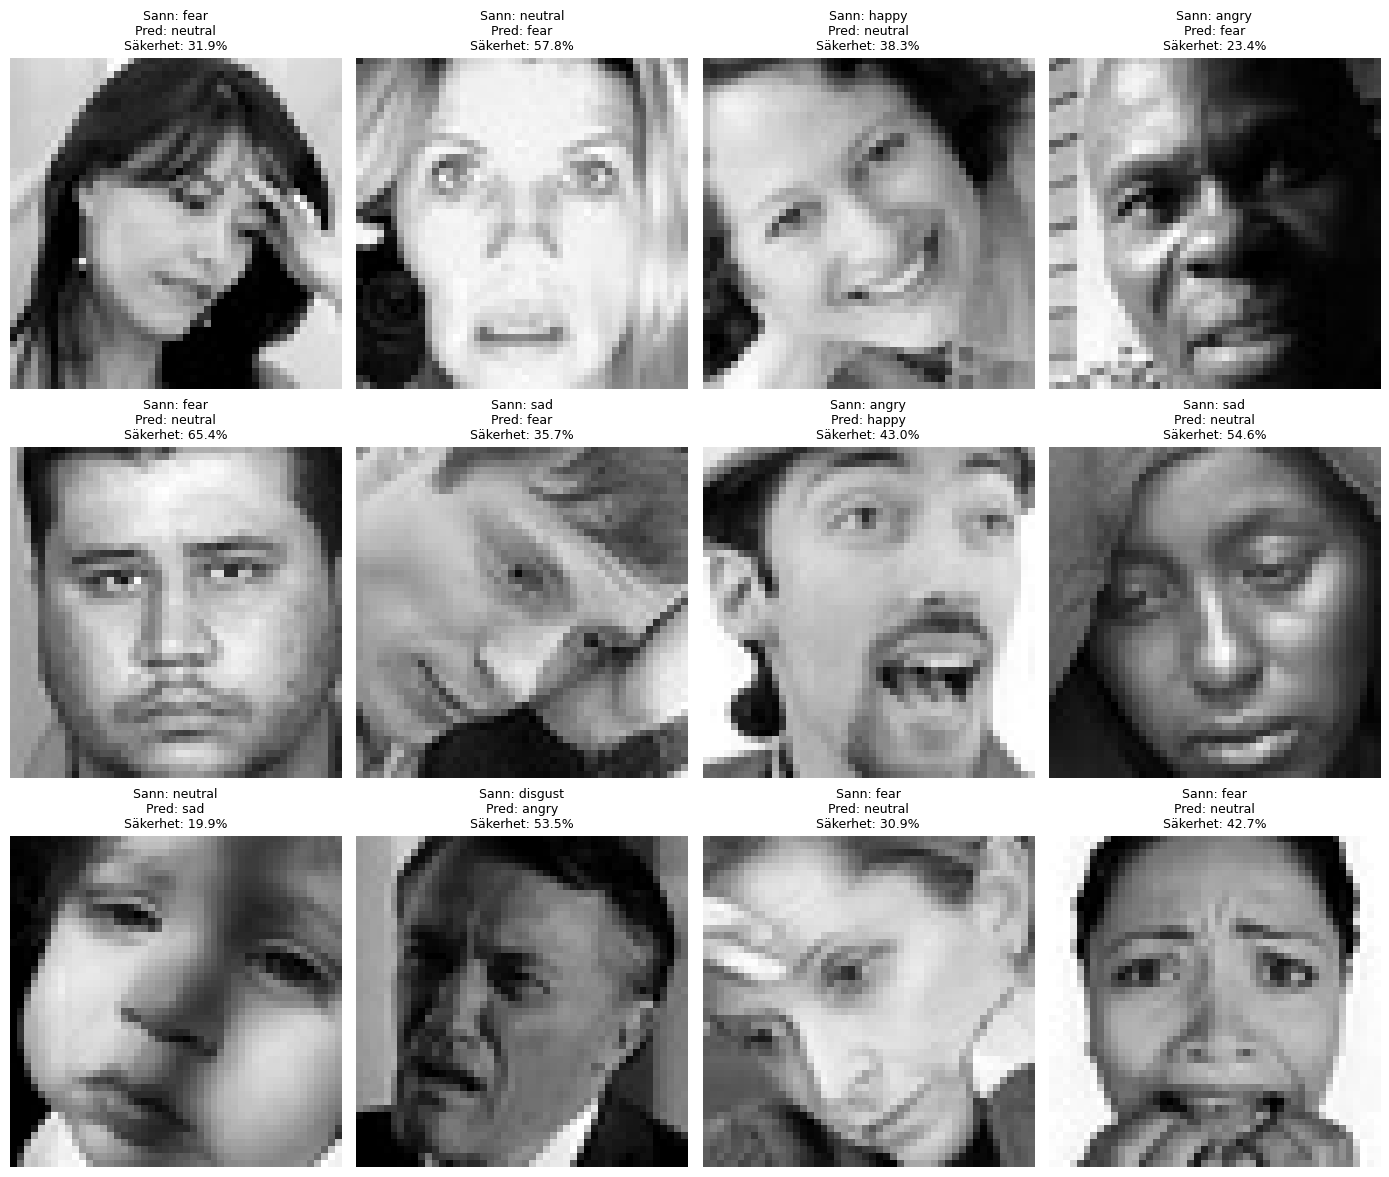

In [22]:
plot_misclassified_examples(
    X_val_small_v2,
    y_val_small_v2,
    improved_y_pred,
    improved_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [23]:
results.append({
    "model": "improved",
    "val_acc": improved_val_acc,
    "val_loss": improved_history_df["val_loss"].min(),
    "epochs_trained": len(improved_history_df),
    "training_time_min": training_time / 60
})

results_df = pd.DataFrame(results)
display(results_df)

,model,val_acc,val_loss,epochs_trained,training_time_min
0,baseline,0.340000,1.620953,10,0.279672
1,improved,0.441875,1.437130,10,1.216907


### 3.3.4 Sammanfattning av improved-modellen

Den förbättrade modellen uppnår högre validation accuracy och lägre validation loss jämfört med baseline-modellen.

Träningskurvorna visar även mindre skillnad mellan tränings- och valideringsresultat, vilket tyder på att overfitting har minskat.

Man ser även förbättrat resultat för flera av majoritetsklasserna, där exempelvis happy och surprise uppnår betydligt högre accuracy.

Samtidigt kvarstår svårigheter för vissa minoritetsklasser, särskilt disgust och fear, vilket sannolikt påverkas av både klassobalans och att uttrycken är visuellt svåra att skilja från andra klasser.


Dropout och större träningsdata verkar ha förbättrat modellens generaliseringsförmåga, även om modellen fortfarande har svårt för vissa klasser med få träningsbilder.

Trots förbättringarna gör modellen fortfarande många felprediktioner, vilket visar att uppgiften är relativt komplex.

### 3.4.1 Improved 2 CNN - större datamängd och Early Stopping

I denna version behålls samma grundarkitektur som i föregående modell, men modellen tränas nu på hela träningsdatan istället för ett mindre subset.

Målet är att undersöka om mer träningsdata kan förbättra modellens generaliseringsförmåga och ge stabilare resultat.

För att minska risken för overfitting används även `EarlyStopping`, vilket avbryter träningen när validation loss slutar förbättras och återställer modellens bästa vikter.

En möjlig förbättring hade varit att testa en djupare modellarkitektur, men eftersom modellen redan visar tillräcklig kapacitet ligger fokus här istället på datamängd och regularisering.

Jämfört med tidigare modeller används:
- hela träningsdatasetet
- EarlyStopping
- samma CNN-arkitektur med dropout

In [24]:
improved2_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(48, 48, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

improved2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

improved2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,245,671 (4.75 MB)

 Trainable params: 1,245,671 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### 3.4.2 Träning av Improved 2-modellen

Modellen tränas på hela träningsdatan med maximalt 20 epoker och earlystopping

Epoch 1/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.2838 - loss: 1.7530 - val_accuracy: 0.3973 - val_loss: 1.5702
Epoch 2/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3938 - loss: 1.5656 - val_accuracy: 0.4059 - val_loss: 1.5137
Epoch 3/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.4398 - loss: 1.4534 - val_accuracy: 0.4736 - val_loss: 1.3688
Epoch 4/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.4707 - loss: 1.3753 - val_accuracy: 0.4954 - val_loss: 1.2962
Epoch 5/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.4890 - loss: 1.3213 - val_accuracy: 0.5118 - val_loss: 1.2672
Epoch 6/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.5104 - loss: 1.2782 - val_accuracy: 0.5201 - val_loss: 1.2552
Epoch 7/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.5239 - loss: 1.2440 - val_accuracy: 0.5241 - val_loss: 1.2368
Epoch 8/20
718/718 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.5377 - loss: 1.2061 - 

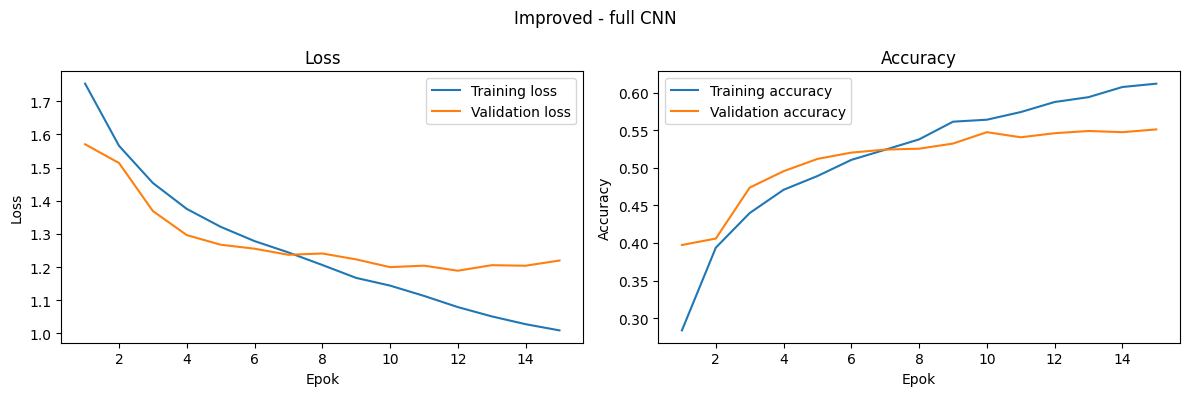

In [26]:
start_time = time.time()

improved2_history = improved2_model.fit(
    train_dataset_full,
    validation_data=validation_dataset_full,
    epochs=20,
    callbacks=[early_stop]
)

training_time = time.time() - start_time

print(f'Träningstid: {training_time / 60:.2f} minuter')

plot_history(improved2_history, title='Improved - full CNN')

### 3.4.3 Observationer från träningen

Modellen förbättras stabilt under större delen av träningen och både tränings- och validation accuracy ökar successivt över flera epoker.

Validation loss fortsätter dessutom att minska under lång tid, vilket tyder på att den större datamängden hjälper modellen att generalisera bättre än tidigare modeller.

Mot slutet av träningen börjar förbättringarna plana ut samtidigt som skillnaden mellan tränings- och validation accuracy ökar något. Detta indikerar att modellen börjar närma sig overfitting, men att EarlyStopping hjälper till att begränsa problemet.

Överlag visar träningskurvorna en stabilare och mer robust inlärning jämfört med tidigare modeller.

In [27]:
improved2_history_df = pd.DataFrame(improved2_history.history)

best_epoch = improved2_history_df['val_loss'].idxmin() + 1
best_val_loss = improved2_history_df['val_loss'].min()
best_val_accuracy = improved2_history_df['val_accuracy'].iloc[best_epoch - 1]

print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')


improved2_y_pred, improved2_y_proba = predict_classes(
    improved2_model,
    X_val_full
)

improved2_val_acc = accuracy_score(y_val_full, improved2_y_pred)

print(f"Improved2 validation accuracy: {improved2_val_acc:.4f}")

Bästa validation loss vid epok: 12
Bästa validation loss: 1.1888
Validation accuracy vid den epoken: 0.5459
Improved2 validation accuracy: 0.5459


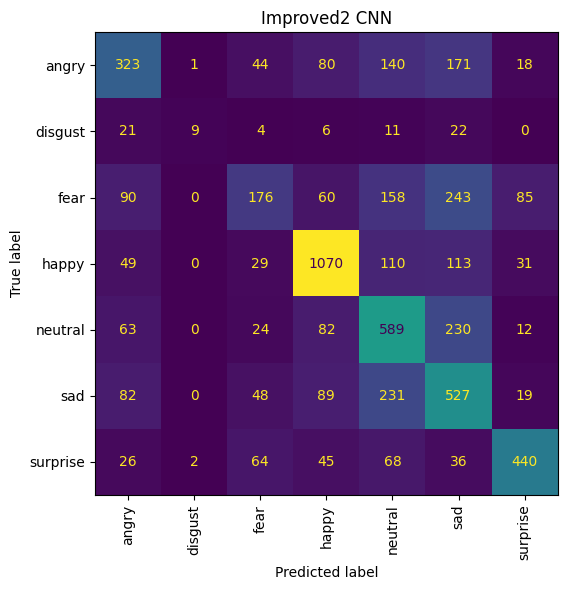

,class_id,class_name,support,correct,accuracy
1,1,disgust,73,9,0.123288
2,2,fear,812,176,0.216749
0,0,angry,777,323,0.415701
5,5,sad,996,527,0.529116
4,4,neutral,1000,589,0.589000
6,6,surprise,681,440,0.646109
3,3,happy,1402,1070,0.763195


,true_class,predicted_class,count
14,fear,sad,243
29,sad,neutral,231
24,neutral,sad,230
4,angry,sad,171
13,fear,neutral,158
3,angry,neutral,140
19,happy,sad,113
18,happy,neutral,110
11,fear,angry,90
28,sad,happy,89


In [28]:
improved2_cm = plot_confusion_matrix(
    y_val_full,
    improved2_y_pred,
    class_names,
    title="Improved2 CNN"
)

improved2_per_class = calculate_per_class_accuracy(
    improved2_cm,
    class_names
)

display(improved2_per_class)

improved2_confusions = get_most_confused_pairs(
    improved2_cm,
    class_names
)

display(improved2_confusions)

Antal felklassificerade exempel: 2607
Andel felklassificerade: 45.41%


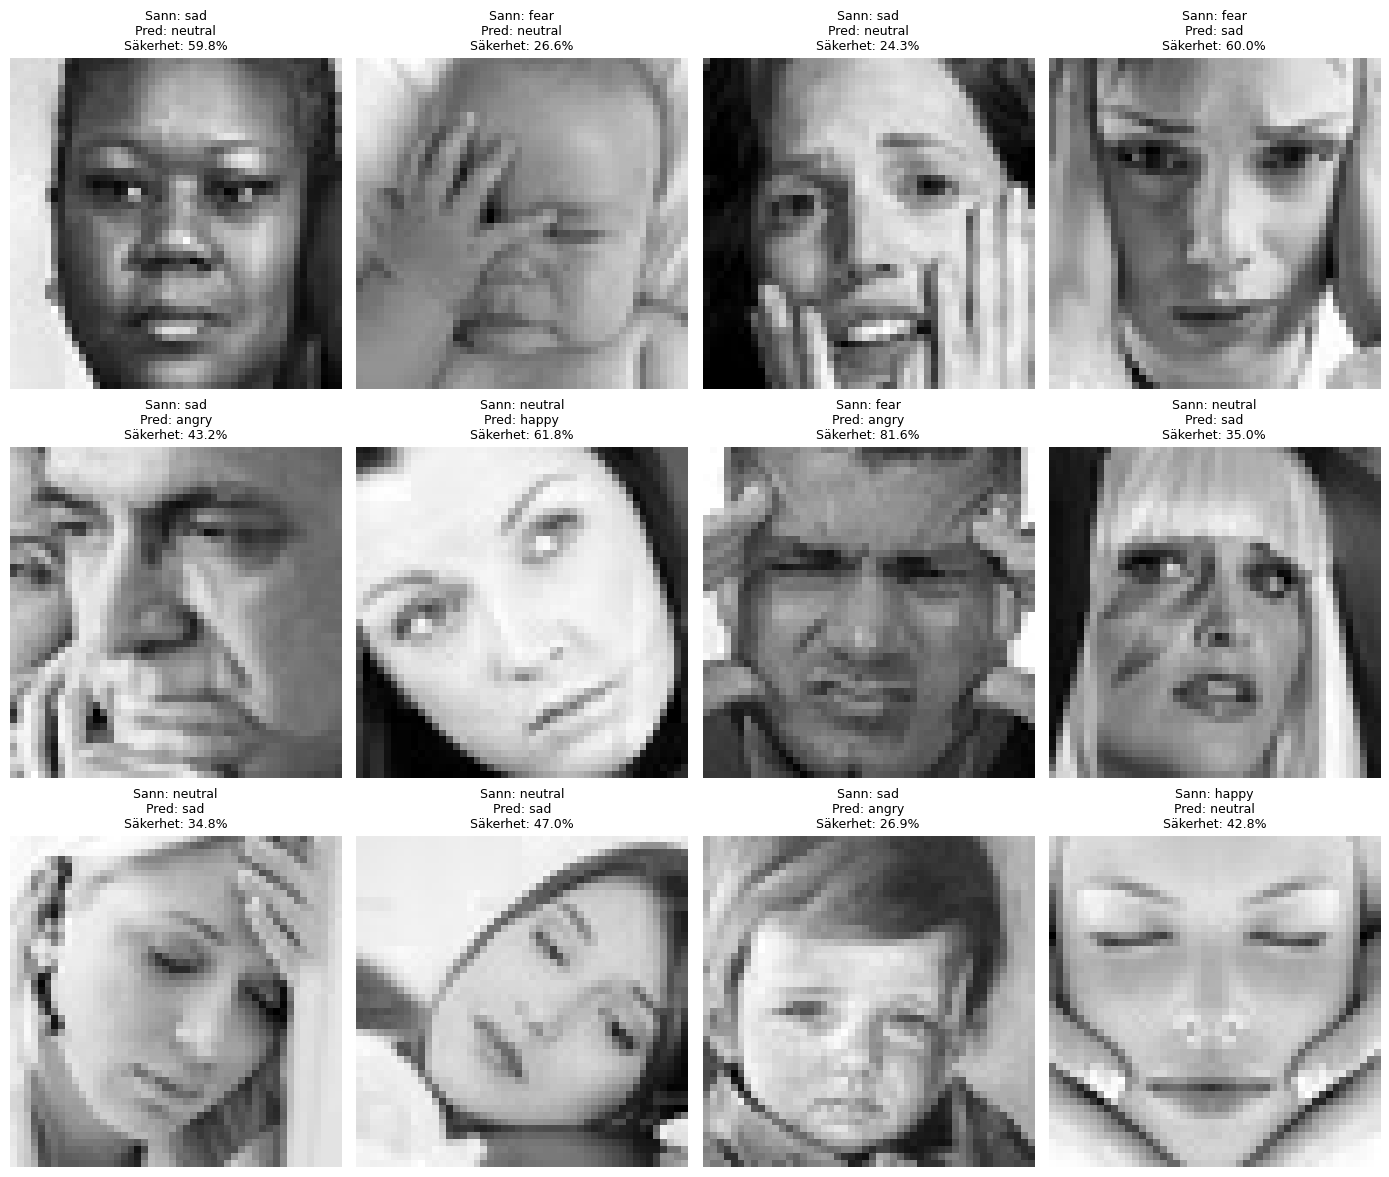

In [29]:
plot_misclassified_examples(
    X_val_full,
    y_val_full,
    improved2_y_pred,
    improved2_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [30]:
results.append({
    "model": "improved_2",
    "val_acc": improved2_val_acc,
    "val_loss": improved2_history_df["val_loss"].min(),
    "epochs_trained": len(improved2_history_df),
    "training_time_min": training_time / 60
})

results_df = pd.DataFrame(results)
display(results_df)

,model,val_acc,val_loss,epochs_trained,training_time_min
0,baseline,0.340000,1.620953,10,0.279672
1,improved,0.441875,1.437130,10,1.216907
2,improved_2,0.545898,1.188783,15,6.881073


### 3.4.4 Sammanfattning av Improved 2-modellen

Improved 2-modellen presterar tydligt bättre än tidigare modeller och visar den starkaste generaliseringsförmågan hittills.

Den större datamängden bidrar till stabilare träning och förbättrad accuracy för flera klasser, särskilt:
- happy
- surprise
- neutral

Även vissa svårare klasser förbättras jämfört med tidigare modeller, även om disgust och fear fortfarande har relativt låg accuracy.

Analysen av confusion matrix visar att modellen fortsatt har svårt att separera vissa visuellt liknande uttryck, särskilt mellan:
- sad och neutral
- fear och sad
- angry och neutral


Resultatet tyder på att större datamängd och regularisering har haft stor påverkan på modellens prestanda.

### 3.5.1 Final CNN - test av data augmentation

I denna modell testas data augmentation för att undersöka om modellen kan generalisera bättre genom att tränas på varierade versioner av bilderna.

Augmentation används endast på träningsdatan och består av:
- horisontell spegling
- mindre rotationer
- mindre zoomförändringar

Tanken är att modellen ska bli mindre känslig för små variationer i ansikten och därmed prestera bättre på ny data.
Övrig arkitektur behålls från föregående modell för att isolera effekten av data augmentation.



In [31]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=42),
    tf.keras.layers.RandomRotation(0.1, seed=42),
    tf.keras.layers.RandomZoom(0.1, seed=42),
])

In [32]:
final_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),

    data_augmentation,

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

### 3.5.2 Träning av finalmodellen

Finalmodellen tränades först på hela träningsdatan med samma träningsinställningar som föregående modell.  

Men då den slutade träna redan efter 3 epoker ökades patience upp till 5 (tidigare 3) 
Modellen lärde sig betydligt långsammare med agumentationen så även epoker ökades till 40 för att ge den en chans att hinna träna tillräkligt länge. 

In [33]:
early_stop_2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Epoch 1/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.2480 - loss: 1.8104 - val_accuracy: 0.2677 - val_loss: 1.7639
Epoch 2/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.2759 - loss: 1.7610 - val_accuracy: 0.3304 - val_loss: 1.6817
Epoch 3/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.3112 - loss: 1.7133 - val_accuracy: 0.3266 - val_loss: 1.6529
Epoch 4/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.3423 - loss: 1.6571 - val_accuracy: 0.4074 - val_loss: 1.5297
Epoch 5/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.3686 - loss: 1.6016 - val_accuracy: 0.4194 - val_loss: 1.4947
Epoch 6/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.3979 - loss: 1.5533 - val_accuracy: 0.4531 - val_loss: 1.4294
Epoch 7/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - accuracy: 0.4073 - loss: 1.5222 - val_accuracy: 0.4579 - val_loss: 1.4047
Epoch 8/40
718/718 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.4158 - loss: 1.4983 - 

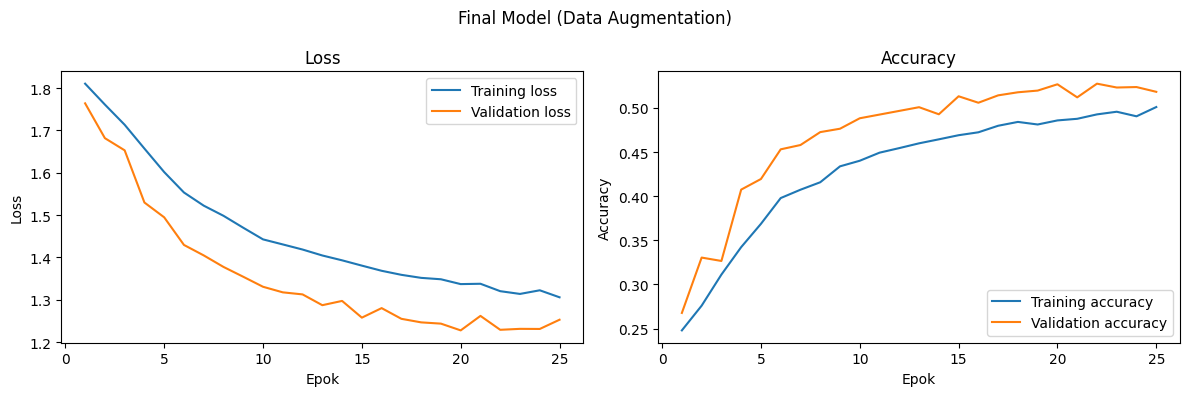

In [34]:
start_time = time.time()

final_history = final_model.fit(
    train_dataset_full,
    validation_data=validation_dataset_full,
    epochs=40,
    callbacks=[early_stop_2]
)

training_time = time.time() - start_time

print(f"Träningstid: {training_time/60:.2f} min")

plot_history(final_history, title="Final Model (Data Augmentation)")

### 3.5.3 Observationer från träningen

Jag började med att ha samma patience(3) i Earlystopping som i tifdigare modell men träningen avbröts redan efter 3 rundor men låg accuracy så testade att höja patience till 5 och även ge modellen fler epoker för att hinna tråna klart


De första experimenten med data augmentation gav betydligt sämre resultat än tidigare modeller. Vid närmare analys visade det sig dock att modellen avbröts för tidigt av EarlyStopping.

När patience ökades kunde modellen tränas längre, vilket gav successivt förbättrad validation accuracy och lägre validation loss.

Detta tyder på att data augmentation gör träningsprocessen långsammare och mer varierande, men samtidigt kan bidra till bättre generalisering när modellen får tillräckligt många epoker för att konvergera.

In [35]:
final_history_df = pd.DataFrame(final_history.history)

best_epoch = final_history_df['val_loss'].idxmin() + 1
best_val_loss = final_history_df['val_loss'].min()
best_val_accuracy = final_history_df['val_accuracy'].iloc[best_epoch - 1]

print(f'Bästa validation loss vid epok: {best_epoch}')
print(f'Bästa validation loss: {best_val_loss:.4f}')
print(f'Validation accuracy vid den epoken: {best_val_accuracy:.4f}')

final_y_pred, final_y_proba = predict_classes(final_model, X_val_full)
final_val_acc = accuracy_score(y_val_full, final_y_pred)

print(f'Final validation accuracy:, {final_val_acc:.4f}')

Bästa validation loss vid epok: 20
Bästa validation loss: 1.2275
Validation accuracy vid den epoken: 0.5267
Final validation accuracy:, 0.5267


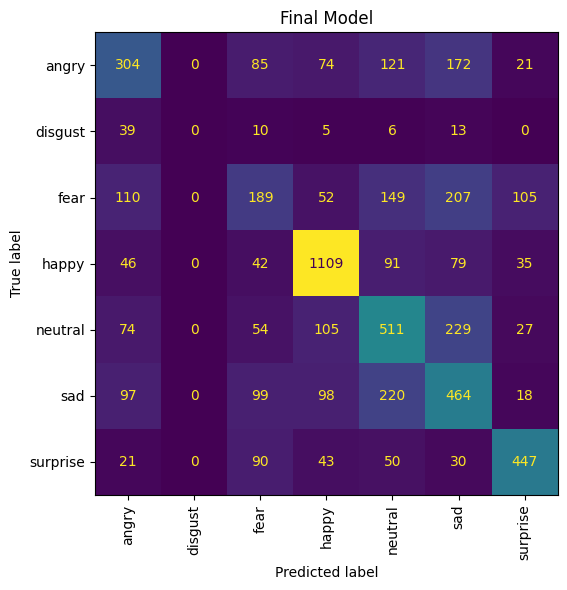

,class_id,class_name,support,correct,accuracy
1,1,disgust,73,0,0.000000
2,2,fear,812,189,0.232759
0,0,angry,777,304,0.391248
5,5,sad,996,464,0.465863
4,4,neutral,1000,511,0.511000
6,6,surprise,681,447,0.656388
3,3,happy,1402,1109,0.791013


,true_class,predicted_class,count
23,neutral,sad,229
28,sad,neutral,220
13,fear,sad,207
3,angry,sad,172
12,fear,neutral,149
2,angry,neutral,121
10,fear,angry,110
14,fear,surprise,105
22,neutral,happy,105
26,sad,fear,99


In [36]:
final_cm = plot_confusion_matrix(
    y_val_full,
    final_y_pred,
    class_names,
    title="Final Model"
)


final_per_class = calculate_per_class_accuracy(
    final_cm, 
    class_names
    )

display(final_per_class)

final_confusions = get_most_confused_pairs(
    final_cm, 
    class_names
    )

display(final_confusions)


Antal felklassificerade exempel: 2717
Andel felklassificerade: 47.33%


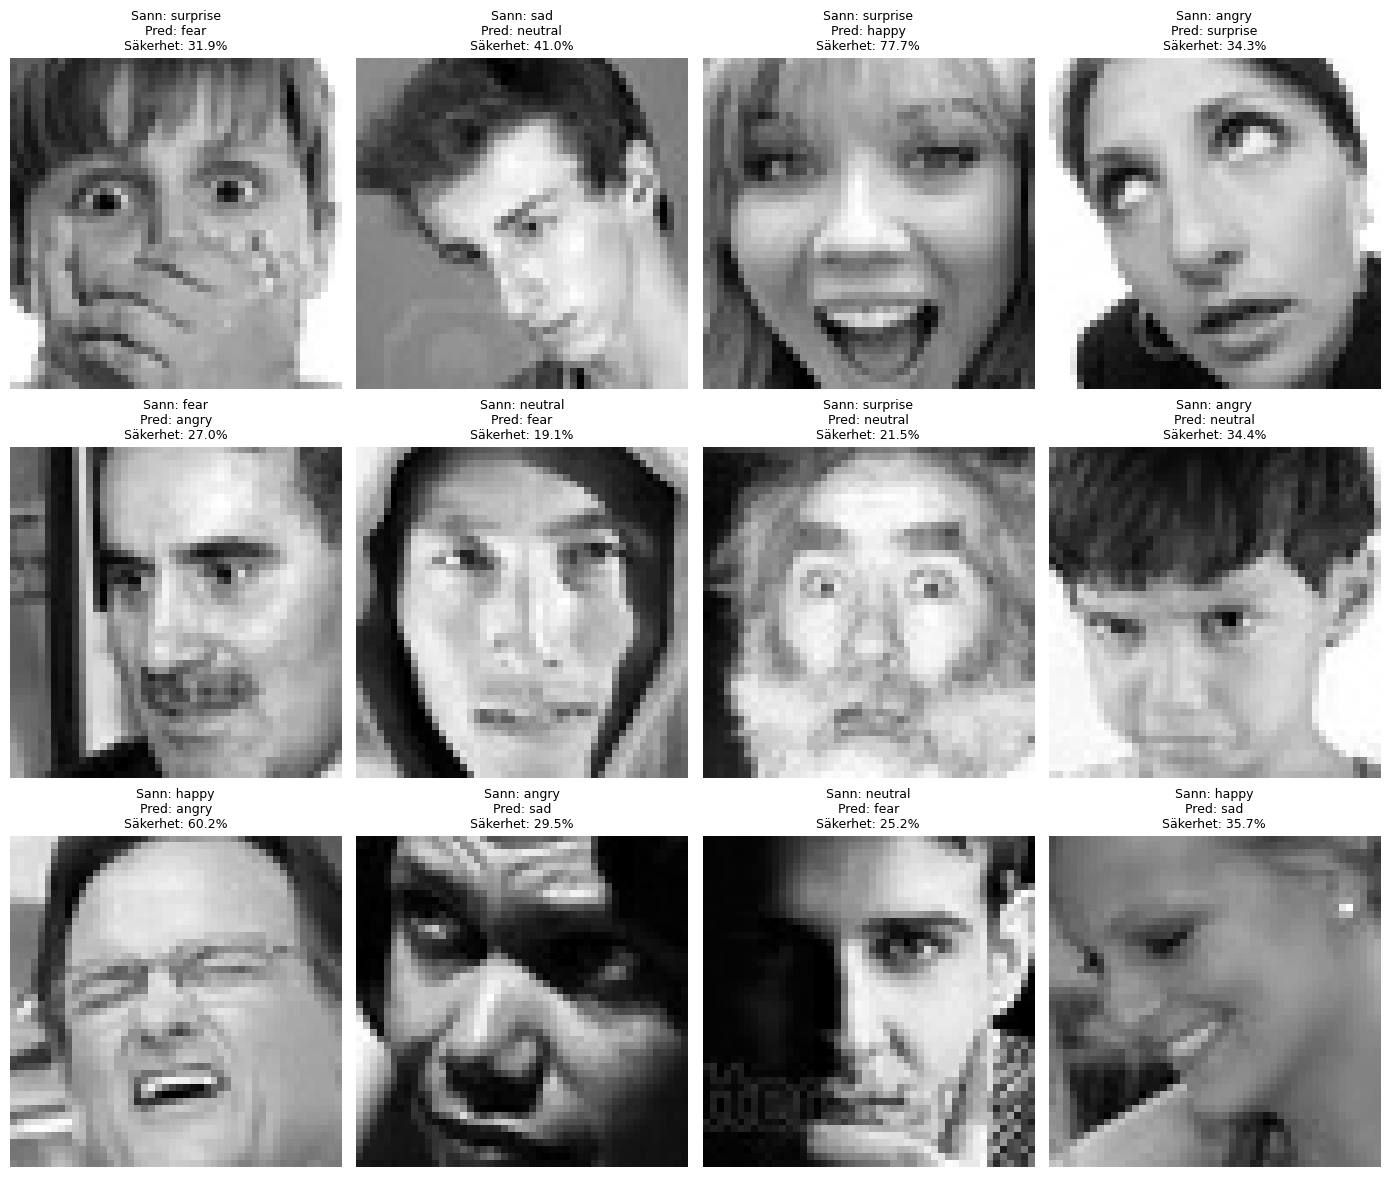

In [37]:
plot_misclassified_examples(
    X_val_full,
    y_val_full,
    final_y_pred,
    final_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

In [38]:
results.append({
    "model": "final (augmentation)",
    "val_acc": final_val_acc,
    "val_loss": final_history_df["val_loss"].min(),
    "epochs_trained": len(final_history_df),
    "training_time_min": training_time / 60
})

results_df = pd.DataFrame(results)
display(results_df)

,model,val_acc,val_loss,epochs_trained,training_time_min
0,baseline,0.340000,1.620953,10,0.279672
1,improved,0.441875,1.437130,10,1.216907
2,improved_2,0.545898,1.188783,15,6.881073
3,final (augmentation),0.526738,1.227549,25,12.373764


### 3.5.4 Jämförelse med tidigare modeller

Till skillnad från tidigare modeller försämrades resultaten tydligt när data augmentation infördes.

Det visar att fler tekniker och mer komplexitet inte alltid leder till bättre resultat. Hur väl en metod fungerar beror på datasetets storlek, bildkvalitet och vilka transformationer som används.

En möjlig förklaring är att bilderna har låg upplösning (48x48 pixlar), vilket gör att rotation och zoom förändrar viktiga ansiktsdrag för mycket.
Därför valde jag att göra ytterligare en final-model v2 där jag testar en mindre aggresiv augmentation

### Slutsats

Denna modell blev projektets bästa modell och visar att:
- större datamängd förbättrade prestandan tydligt
- dropout och early stopping hjälpte generaliseringen
- försiktig data augmentation gav ytterligare förbättring
- kraftig augmentation var däremot skadlig för emotionklassificering

Experimentet visar också hur känsligt emotionigenkänning är för förändringar i ansiktsbilder och att augmentation måste anpassas försiktigt till problemdomänen.

## 8. Slutlig modelljämförelse

För att sammanfatta experimenten samlades samtliga modeller i en gemensam jämförelsetabell. Tabellen innehåller validation accuracy, validation loss, antal tränings-epoch samt träningstid för varje modell.

Denna tabell ger en översiktlig bild av hur olika val av arkitektur, datamängd och regularisering påverkar modellens prestanda.

In [39]:
results_df = pd.DataFrame(results)
display(results_df)

,model,val_acc,val_loss,epochs_trained,training_time_min
0,baseline,0.340000,1.620953,10,0.279672
1,improved,0.441875,1.437130,10,1.216907
2,improved_2,0.545898,1.188783,15,6.881073
3,final (augmentation),0.526738,1.227549,25,12.373764


Resultaten visar en tydlig utveckling mellan modellerna där varje förbättringsiteration generellt leder till bättre validation accuracy.

Den bästa modellen uppnår högst accuracy och lägst validation loss, vilket indikerar att kombinationen av djupare arkitektur och data augmentation bidrar till förbättrad generalisering.

Samtidigt framgår det att förbättringarna inte är linjära, utan att vissa experiment med kraftigare augmentation initialt leder till försämrad prestanda.

Flera viktiga mönster kan observeras i resultaten:

Djupare CNN-arkitektur förbättrar modellens kapacitet och ger tydlig prestandaökning jämfört med baseline.
Dropout bidrar till stabilare träning och minskar överfitting.
Försiktig data augmentation (t.ex. liten rotation och horisontell flip) förbättrar generalisering.
För kraftig augmentation kan däremot försämra prestandan genom att förändra viktiga kännetecken i ansiktsuttryck.
Klassobalans påverkar fortfarande resultatet, där minoritetsklasser som disgust och fear är svårare att klassificera korrekt.

Den bästa modellen i experimentet är final_v2 (light augmentation), som uppnår högst validation accuracy och lägst validation loss.

Modellen visar en bättre balans mellan träning och generalisering jämfört med tidigare versioner och hanterar valideringsdata mer stabilt.

## Spar modell

In [40]:
best_model = improved2_model

best_model.save("best_emotion_model.keras")
print("Modellen sparades!")


loaded_model = tf.keras.models.load_model("best_emotion_model.keras")
print("Modellen laddades!")

Modellen sparades!
Modellen laddades!


## Evaluate på testdataset

In [ ]:
test_loss, test_accuracy = loaded_model.evaluate(test_dataset)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

# Extrahera dataset
X_test, y_test = extract_dataset(test_dataset)

test_y_pred, test_y_proba = predict_classes(
    loaded_model,
    X_test
)

test_acc = accuracy_score(y_test, test_y_pred)

print(f"Test accuracy: {test_acc:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5543 - loss: 1.1752
Test loss: 1.1752
Test accuracy: 0.5543
Test accuracy: 0.5543


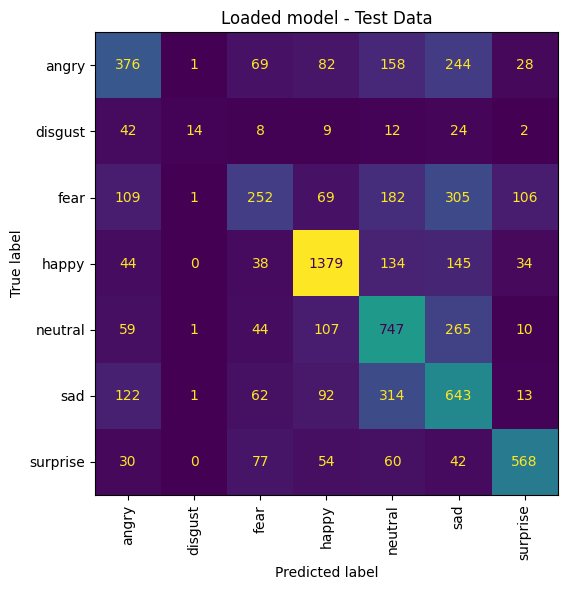

In [42]:
test_cm = plot_confusion_matrix(
    y_test,
    test_y_pred,
    class_names,
    title="Loaded model - Test Data"
)

Antal felklassificerade exempel: 3199
Andel felklassificerade: 44.57%


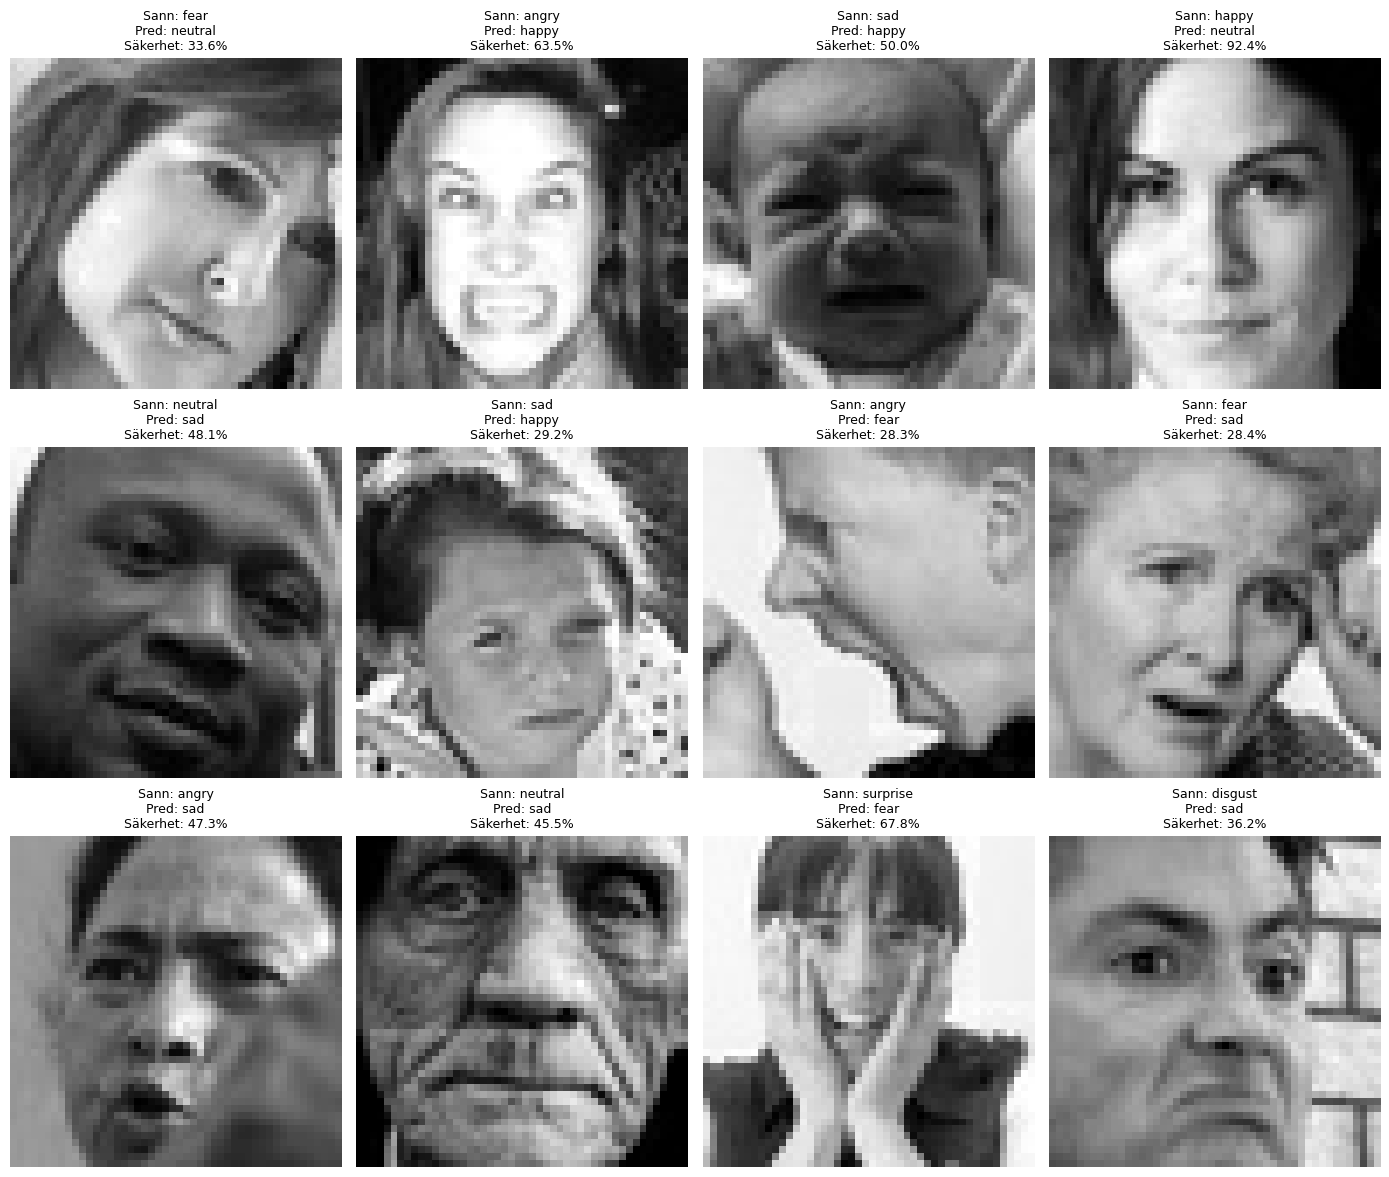

In [43]:
plot_misclassified_examples(
    X_test,
    y_test,
    test_y_pred,
    test_y_proba,
    class_names,
    n_images=12,
    random_state=42
)

## Sluttest

Nedan kan man välja en bild från testdatan för att se hur väl modellen predikterar.


In [58]:
print(f"För att välj en bild sätt index till en siffra mellan 0 och {len(X_test)-1}")

För att välj en bild sätt index till en siffra mellan 0 och 7177


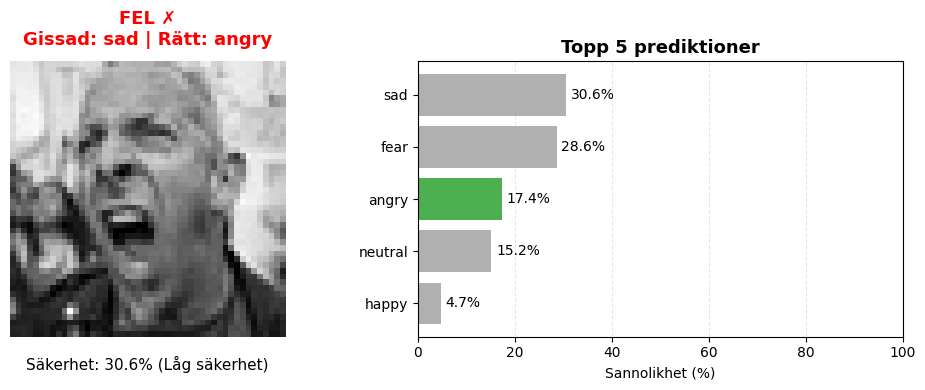

In [75]:
index = 7

show_prediction(
    image_index=index,
    X_data=X_test,
    y_data=y_test,
    y_proba=test_y_proba,  
    class_names=class_names
)